---
jupyter: false
---

# Motion Energy
Here we'll talk about **motion energy** which is a simple way to measure how much a video changes from one frame to the next. In this project, motion energy is useful because writing and drawing are movement-based tasks. A motion-energy time series gives us a compact measure of when the hand is moving more or less during a trial.

**Learning goals**
- Understand motion energy as frame-to-frame change.
- Connect the computation to a mathematical definition: sum of absolute differences.
- Recognize what motion energy captures well and what can fool it.
- Interpret a motion-energy time series from one standardized video.

**Big picture**

Motion energy is not a full model of movement. It does not tell us the exact hand position or movement direction. But it is a useful first feature because it converts a video into a one-dimensional time series.

## Configure

This section sets the dataset location and chooses one standardized video to analyze.

`LoadVideo.get_data_root()` looks for an environment variable named `VIDEO_PATH` or `DATA_ROOT` that points to the dataset root folder. If you are not sure which video IDs exist, use `lv.list_video_ids(DATA_ROOT)` and choose one.

Frames are read with OpenCV, so color frames are in **BGR** order rather than RGB. That mainly matters for visualization and grayscale conversion.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import LoadVideo as lv
import inspect

DATA_ROOT = lv.get_data_root()
video_id = "vid_000010"

## Define Motion Energy

At its core, motion energy compares two consecutive frames and measures the total amount of pixel-wise change.

Let frames be images $F_t$ and $F_{t+1}$. A common definition is the **sum of absolute differences**:

$$ME(t) = \sum_{x,y,c} |F_{t+1}(x,y,c) - F_t(x,y,c)|$$

Large values mean that a lot changed between two frames. Small values mean that the image stayed mostly the same.

Why use absolute differences? Without the absolute value, positive and negative pixel changes could cancel each other out. Taking the absolute value makes all change count as change.

**What motion energy captures**

- Hand, pen, or arm movement.
- Large changes in the scene.
- Moments when activity increases or decreases.

**What can fool it**

- Lighting changes.
- Camera motion.
- Shadows, sensor noise, or compression artifacts.

This is why motion energy is useful but limited. Later, we combine it with hand-position features extracted from masks.


In [7]:
from MotionEnergy import moeng_framepairs, moeng_video

### Motion Energy Between Two Frames

The function `moeng_framepairs(frame1, frame2)` implements the definition above.

Steps:

1. Optionally convert both frames to grayscale.
2. Check that both frames have the same shape.
3. Compute the absolute pixel-wise difference.
4. Sum the difference image into one number.

The difference image still contains spatial information, but the final motion-energy value collapses it into a single scalar.


In [8]:
lines = inspect.getsource(moeng_framepairs)
print(lines)

def moeng_framepairs(frame1: np.ndarray, frame2: np.ndarray, force_gray: bool = False) -> float:
    if force_gray:
        if frame1.ndim == 3:
            frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        if frame2.ndim == 3:
            frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    if frame1.shape != frame2.shape:
        raise ValueError(f"Frame shape mismatch: {frame1.shape} vs {frame2.shape}")

    diff_frame = cv2.absdiff(frame1, frame2)
    return float(np.sum(diff_frame))



### Motion Energy Across a Whole Video

A video is a sequence of frames. To get a time series, we compute motion energy for each consecutive frame pair:

$(F_0, F_1), (F_1, F_2), \ldots$

The helper `moeng_video(video_np_array)` returns a table with one row per frame pair:

- `FrameIndex`: the index of the second frame in the pair.
- `MotionEnergy`: the amount of change from the previous frame.

Frame rate matters. At higher FPS, adjacent frames are closer together in time, so the raw motion-energy values may be smaller for the same real-world movement.


In [9]:
print(inspect.getsource(moeng_video))

def moeng_video(video_np_array: np.ndarray, force_gray: bool = False) -> pl.DataFrame:
    video_np_array = np.asarray(video_np_array)
    if video_np_array.ndim not in (3, 4):
        raise ValueError(f"Expected video array with 3 or 4 dims, got {video_np_array.ndim}")

    if video_np_array.shape[0] < 2:
        return pl.DataFrame({
            "FrameIndex": pl.Series([], dtype=pl.Int32),
            "MotionEnergy": pl.Series([], dtype=pl.Float64),
        })

    rows = []
    for i in range(1, video_np_array.shape[0]):
        frame1 = video_np_array[i - 1]
        frame2 = video_np_array[i]
        energy = moeng_framepairs(frame1, frame2, force_gray=force_gray)
        rows.append({"FrameIndex": i, "MotionEnergy": energy})

    return pl.DataFrame(rows).with_columns(
        pl.col("FrameIndex").cast(pl.Int32)
    )



## Try It on One Video

This section loads one standardized video, computes motion energy over time, and plots the result.

How to read the plot:

- Peaks often correspond to larger movements.
- Low regions indicate little frame-to-frame change.
- If the curve is high everywhere, check for camera motion or unstable lighting.

Things to try:

- Change `video_id` and compare trials.
- Set `force_gray=True` in `moeng_video()` and compare the curve.
- Compare motion energy across task types after feature extraction.


Video ID: vid_000010
Full video path: G:\My Drive\TEACH_lumier_mledu\Repo\Data\vid_000010\standardized.mp4
Reading frames from: G:\My Drive\TEACH_lumier_mledu\Repo\Data\vid_000010\standardized.mp4

Successfully read 151 frames.
Shape + DType of the video array: (151, 356, 356, 3),uint8
Shape + DType of the video array: (151, 356, 356, 3),uint8

Motion Energy Time Series DataFrame created:
shape: (5, 2)
┌────────────┬──────────────┐
│ FrameIndex ┆ MotionEnergy │
│ ---        ┆ ---          │
│ i32        ┆ f64          │
╞════════════╪══════════════╡
│ 1          ┆ 397192.0     │
│ 2          ┆ 575124.0     │
│ 3          ┆ 571622.0     │
│ 4          ┆ 604742.0     │
│ 5          ┆ 305614.0     │
└────────────┴──────────────┘

Total entries in DataFrame: 150


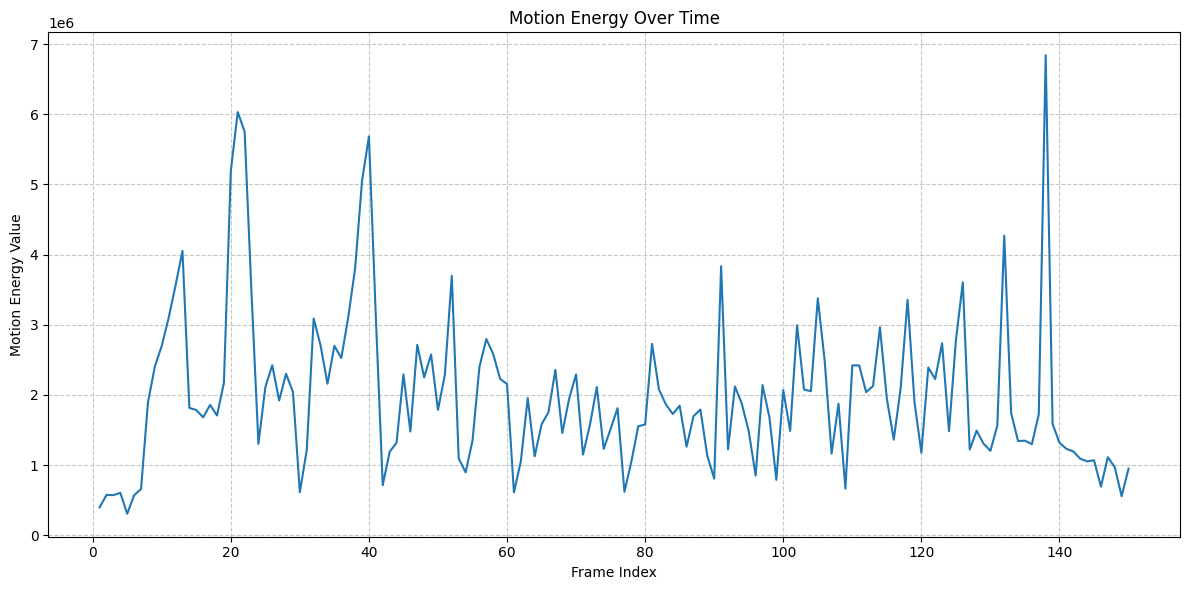

In [10]:
vid_full_path = lv.get_video_file(video_id, kind="standardized", video_root=DATA_ROOT)
assert vid_full_path.is_file(), f"Missing standardized video: {vid_full_path}"
print(f"Video ID: {video_id}")
print(f"Full video path: {vid_full_path}")

video_np_array = lv.get_np_video_array(
    vid_full_path,
    verbose=True,
    plot_eg_frame=False,
)

# force_gray=False keeps all color channels in the motion-energy calculation.
df_me = moeng_video(video_np_array, force_gray=False)
print("\nMotion Energy Time Series DataFrame created:")
print(df_me.head())
print(f"\nTotal entries in DataFrame: {len(df_me)}")

pandas_df = df_me.to_pandas()
plt.figure(figsize=(12, 6))
sns.lineplot(data=pandas_df, x="FrameIndex", y="MotionEnergy")
plt.title("Motion Energy Over Time")
plt.xlabel("Frame Index")
plt.ylabel("Motion Energy Value")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Takeaway

Motion energy is a simple computer vision feature: it measures how much the image changes over time. In the next notebook, we use masking and tracking to extract more specific features, including hand position, speed, direction, and motion energy from different masks.
